In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250525 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

if __name__ == "__main__":
    base_folder = "/data/big_rim/rsync_dcc_sum/25juneon" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
    # save_path = os.path.join(base_folder, 'paret')
    failed_paths_file = None #'/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed_brws.txt'  # File containing failed paths

    force_rescan_rec_files = [
        # ('2023-10-01', '001'),
        # ('2023-10-02', '002'),
        # Add more as needed
    ]
    rescan_threshold_days = 0.001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

    log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                              force_rescan_rec_files=force_rescan_rec_files,
                              rescan_threshold_days=rescan_threshold_days)


Log for 20250519PMCL23L2_enewcone_econe_oldecone saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_24/20250519PMCL23L2_enewcone_econe_oldecone/folder_log.parquet
Log for 20250519PMCL23L2_enewcone saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_24/20250519PMCL23L2_enewcone/folder_log.parquet
Log for 20250519PMCL23L2_scone saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_24/20250519PMCL23L2_scone/folder_log.parquet
Log for 20250407v1l23_ecups saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_ecups/folder_log.parquet
Log for 20250505v123r1 saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250505v123r1/folder_log.parquet
Log for 20250407v1l23_socialclearcup saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_socialclearcup/folder_log.parquet
Log for 20250407v1l23_socialblackcup_2 saved at /data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_socialblackcup_2/folder_log.parquet
Log for 20250407v1l23_socialblackcup saved

In [2]:
sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1"
all_df = read_all_parquet_files(base_folder)

In [9]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   # pc.equal(table['mir_generate_param'], '0'),
   pc.equal(table['sync'], '1'),
   pc.not_equal(table['sync'], '3'),
   pc.equal(table['com'], '1'),
   # pc.equal(table['com_vis'], '1'),
   # pc.equal(table['v1'], '1'),
   pc.equal(table['dannce'], '1'),
   # pc.equal(table['dannce_vis'], '1'),
   # pc.equal(table['social'], '1'),
   pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync'], '1'), # mini_rec_sync_com
   pc.equal(table['date_folder'], '2025_07_08'),
   #mini_rec_sync
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)



# Apply the filter and print the results
filtered_table = table.filter(filter_mask)

# Print each row of the filtered table
print(filtered_table.to_pandas())  # This will display the filtered data in a familiar pandas-like format


   mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                   1    1             1            0   1       1      0   
1                   1    1             1            0   1       1      0   
2                   1    1             1            0   1       1      0   
3                   1    1             1            0   1       1      0   
4                   1    1             1            0   1       1      0   
5                   1    1             1            0   1       1      0   
6                   1    1             1            0   1       1      0   
7                   1    1             1            0   1       1      0   
8                   1    1             1            0   1       1      0   
9                   1    1             1            0   1       1      0   
10                  1    1             1            0   1       1      0   
11                  1    1             1            0   1       1      0   
12          

In [4]:
# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

# Print each path
for path in rec_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup


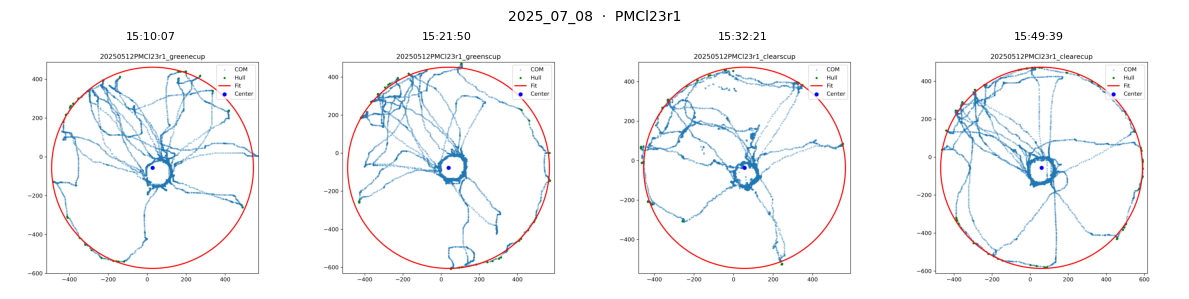

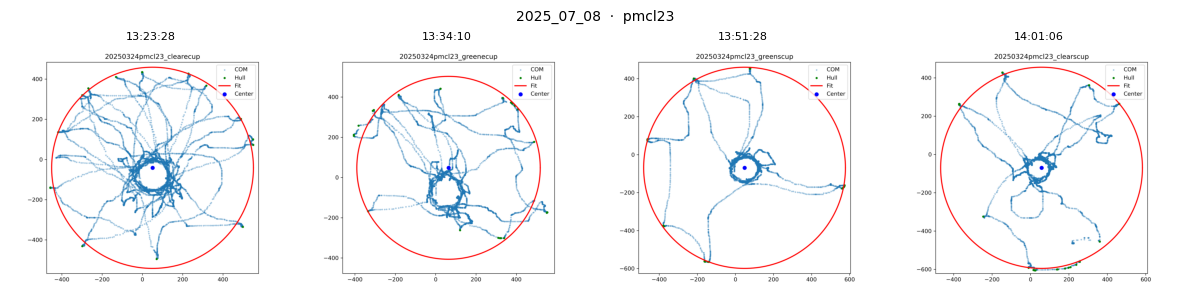

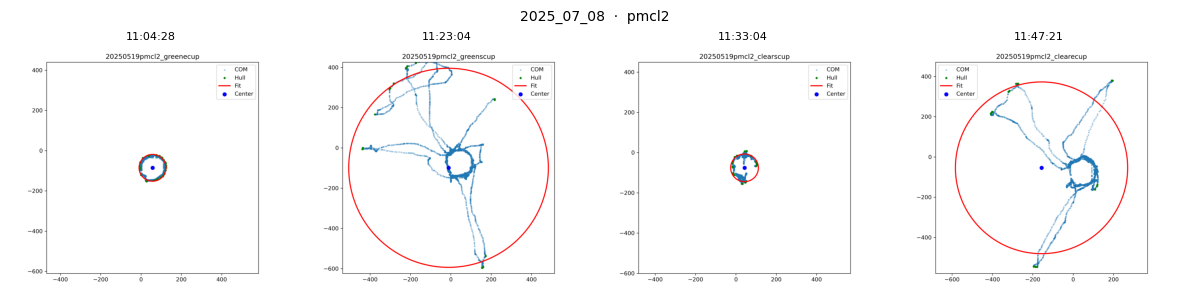

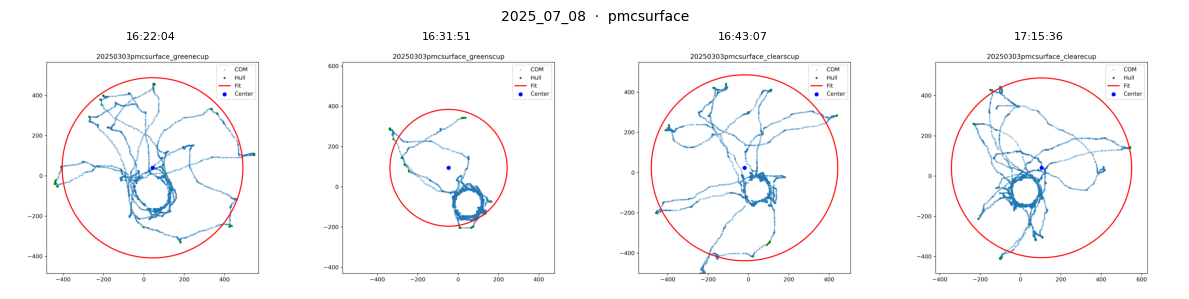

In [5]:
import os
import re
from collections import defaultdict
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

base_paths = []

# Print each path
for path in rec_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    base_paths.append(path[0] if isinstance(path, list) else path)

# 1. Collect (path, modification time) for each frametimes.mat
sessions = []
for p in base_paths:
    ft = os.path.join(p, "videos", "Camera1", "frametimes.mat")
    if os.path.isfile(ft):
        mtime = os.path.getmtime(ft)
        sessions.append((p, mtime))
    else:
        print(f"Warning: frametimes.mat not found for {p}")

# 2. Group by (day, animal)
groups = defaultdict(list)
for p, mtime in sessions:
    day = os.path.basename(os.path.dirname(p))            # e.g. "2025_06_17"
    folder = os.path.basename(p)                          # e.g. "20250407V1L23r1blkcap_econe…"
    m = re.match(r"^(\d{8})([A-Za-z0-9]+)", folder)       # date + animalID
    if not m:
        continue
    date_str, animal = m.groups()
    groups[(day, animal)].append((p, mtime))

# 3. For each (day, animal), sort and plot
for (day, animal), items in groups.items():
    items.sort(key=lambda x: x[1])  # chronological
    n = len(items)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    if n == 1:
        axes = [axes]
    for ax, (p, mtime) in zip(axes, items):
        img_file = os.path.join(p, "vis", "com_circle.png")
        if os.path.isfile(img_file):
            img = mpimg.imread(img_file)
            ax.imshow(img)
            ts = datetime.fromtimestamp(mtime).strftime("%H:%M:%S")
            ax.set_title(ts, fontsize=8)
        else:
            ax.text(0.5, 0.5, "no image", ha="center", va="center")
        ax.axis("off")
    fig.suptitle(f"{day}  ·  {animal}", fontsize=10)
    plt.tight_layout()
    plt.show()

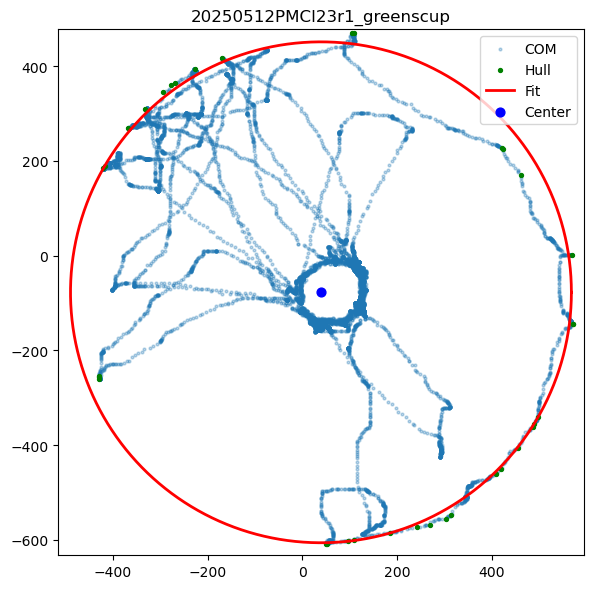

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup/vis/com_circle.png


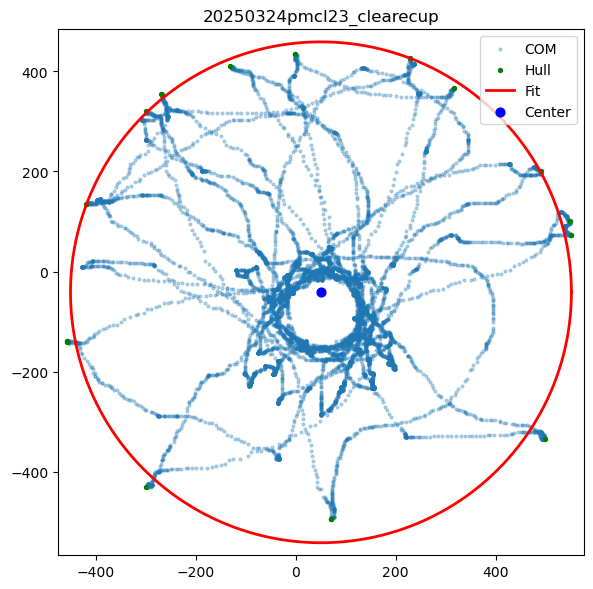

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_clearecup/vis/com_circle.png


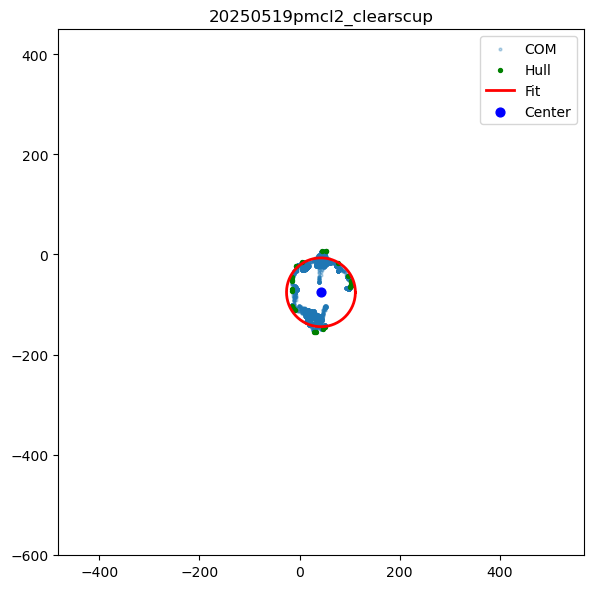

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup/vis/com_circle.png


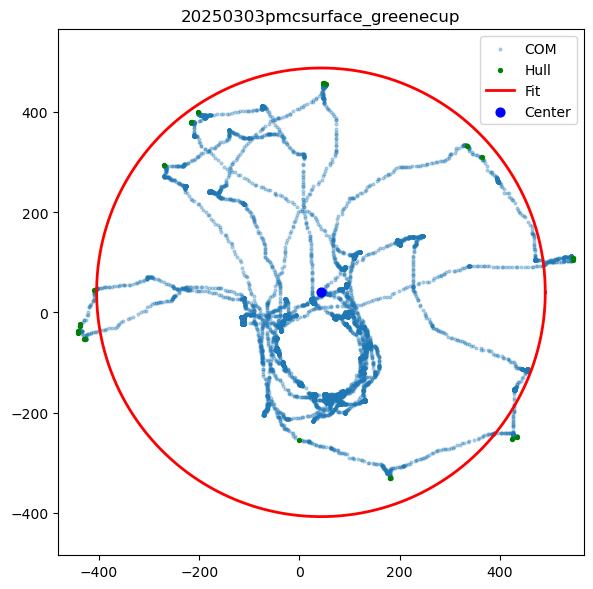

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250303pmcsurface_greenecup/vis/com_circle.png


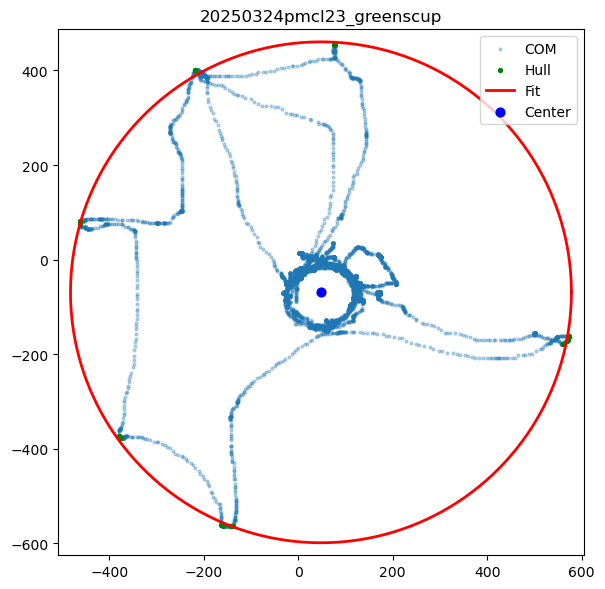

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_greenscup/vis/com_circle.png


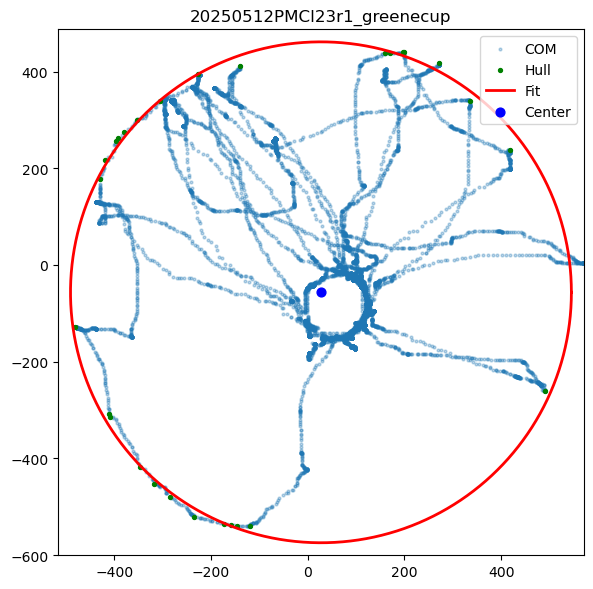

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup/vis/com_circle.png


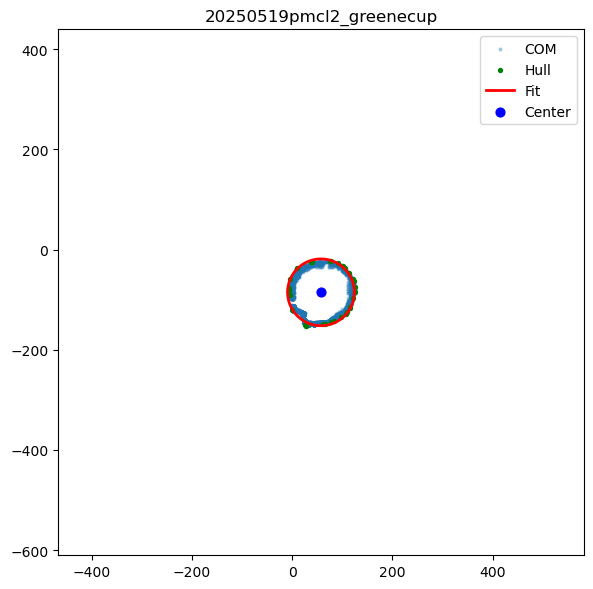

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup/vis/com_circle.png
Primary COM file not found; using fallback: /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup/COM/predict00/com3d0.mat


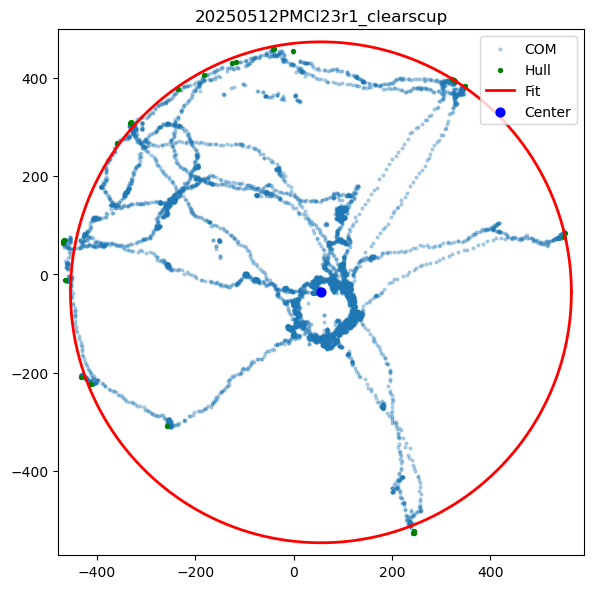

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup/vis/com_circle.png


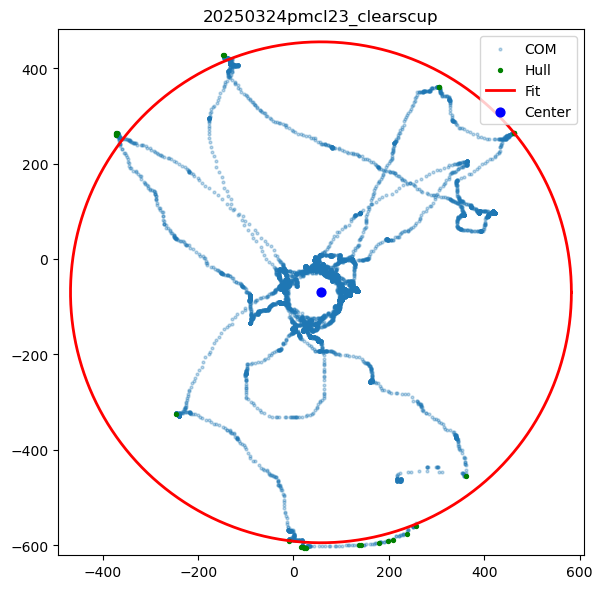

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_clearscup/vis/com_circle.png


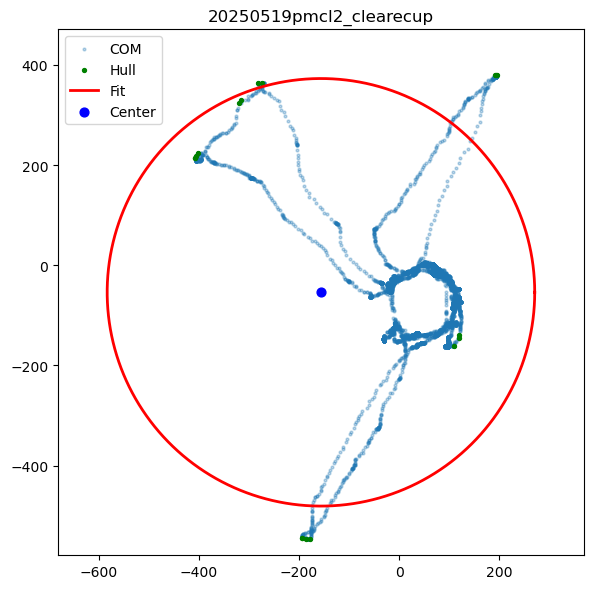

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup/vis/com_circle.png


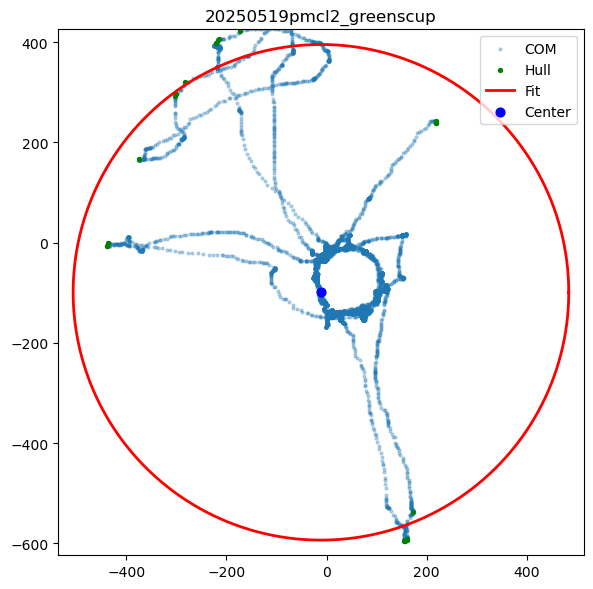

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup/vis/com_circle.png


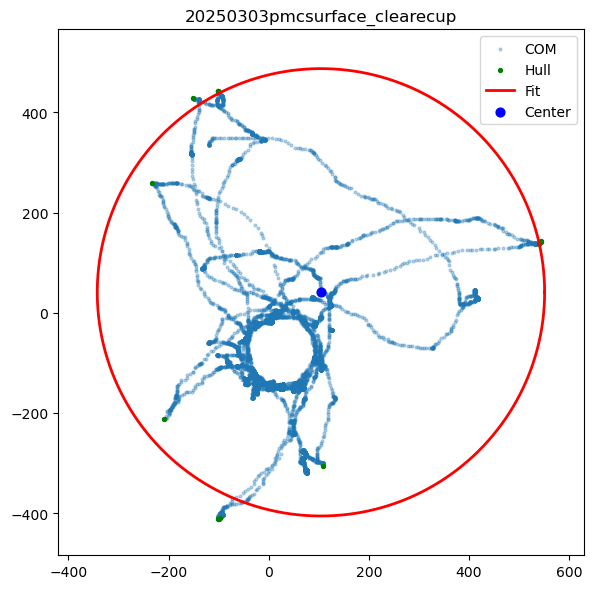

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250303pmcsurface_clearecup/vis/com_circle.png


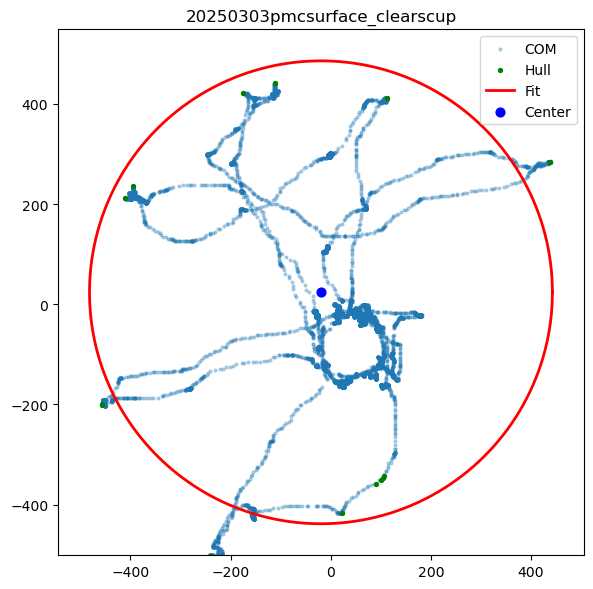

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250303pmcsurface_clearscup/vis/com_circle.png


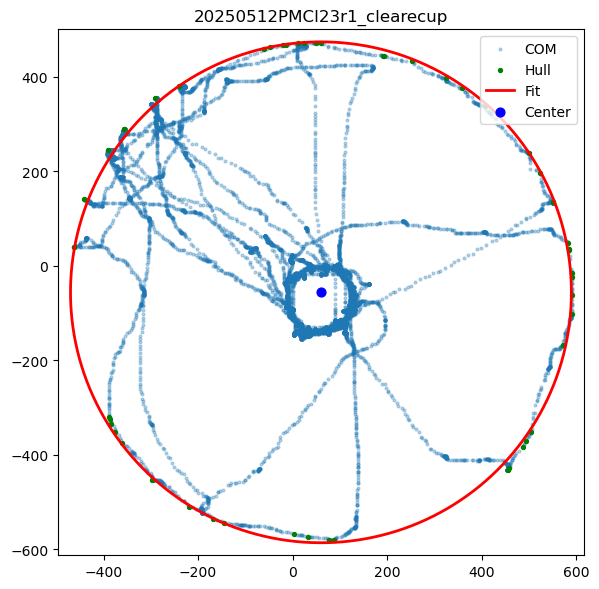

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup/vis/com_circle.png


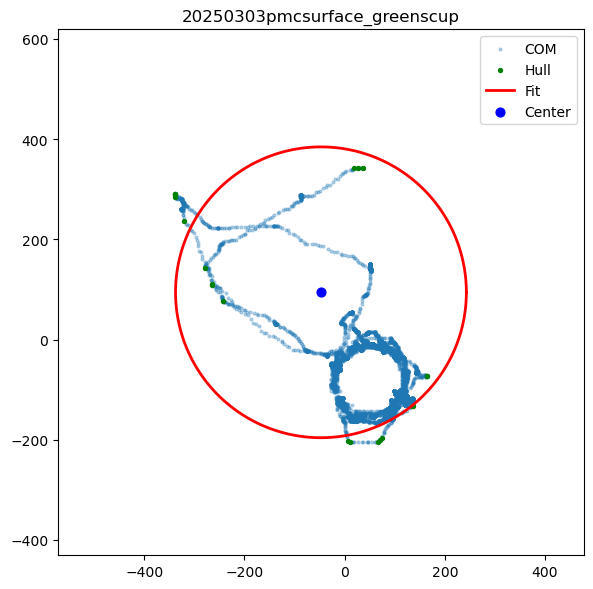

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250303pmcsurface_greenscup/vis/com_circle.png


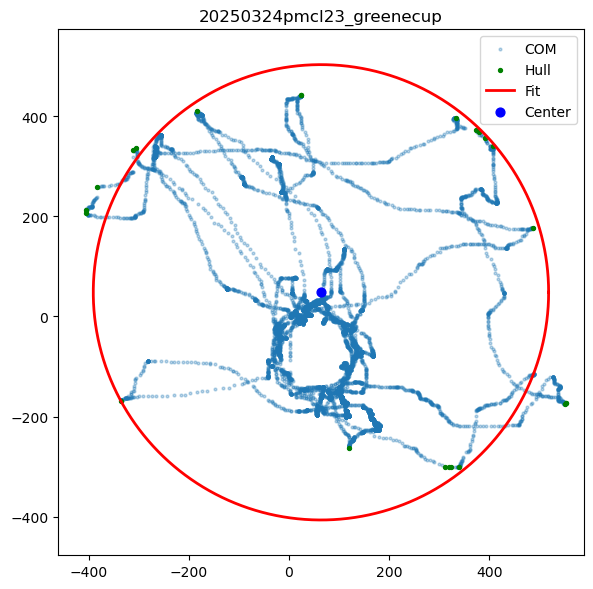

Saved COM circle plot to:
  /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_greenecup/vis/com_circle.png


In [4]:
from utlis.vis_valid_utlis.com_trace import plot_com_circle_for_path
from pathlib import Path
# META = os.path.join(base_folder,"meta_com_estimation","table_dims_meta.csv")
META = Path(base_folder) / "meta_com_estimation" / "table_dims_meta.csv"
META.parent.mkdir(parents=True, exist_ok=True)

rec_paths = filtered_table.column('rec_path').to_pylist()

# 3. Loop through and plot
for path in rec_paths:
    try:
        # plot_com_circle_for_path(path)
        plot_com_circle_for_path(path) #manual_dims=(100,50,60), meta_csv=META
    except Exception as e:
        print(f"❌ Failed on {path!r}: {e}")

First five sessions:
                                        session_path         xc         yc  \
0  /data/big_rim/rsync_dcc_sum/25juneon/2025_06_1...  12.906650  35.247325   
1  /data/big_rim/rsync_dcc_sum/25juneon/2025_06_1...  15.764734  35.975097   
2  /data/big_rim/rsync_dcc_sum/25juneon/2025_06_1...  11.395518  41.884416   
3  /data/big_rim/rsync_dcc_sum/25juneon/2025_06_1...  19.019653  27.755401   
4  /data/big_rim/rsync_dcc_sum/25juneon/2025_06_1...   5.169539  41.357365   

            r  
0  546.487827  
1  525.337101  
2  537.916477  
3  528.324798  
4  520.453360   

Summary statistics for xc, yc, r:
               xc          yc           r
count   39.000000   39.000000   39.000000
mean    57.952138   23.695361  484.663648
std    127.074970   71.579345  108.462829
min   -156.332243  -99.101196   66.657781
25%    -14.811651  -41.289534  497.729339
50%     35.336333   35.975097  521.818528
75%     58.780207  100.087687  531.452281
max    322.899301  148.927162  546.487827 

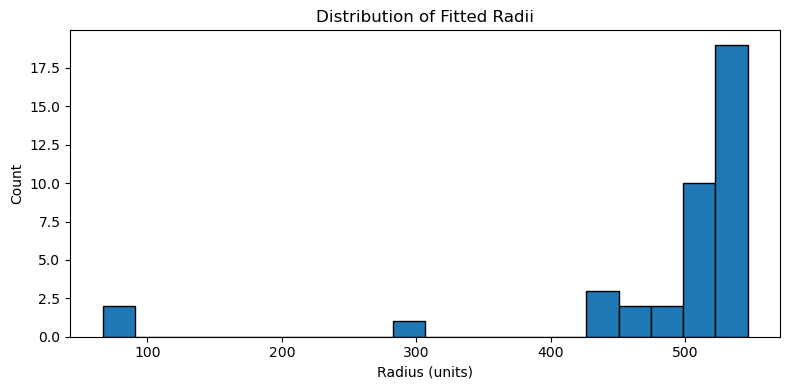

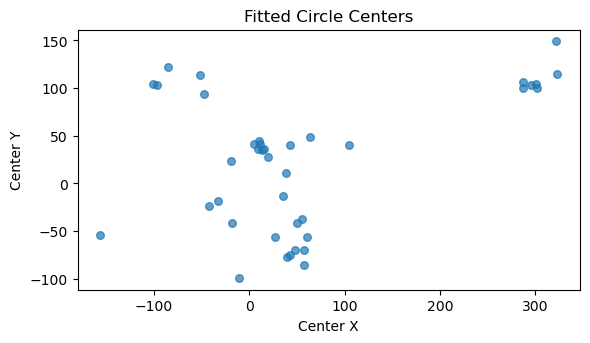

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── UPDATE THIS ───
meta_csv =META
# ────────────────────

# 1) Load
df = pd.read_csv(meta_csv)

# 2) Quick peek
print("First five sessions:")
print(df.head(), "\n")
print("Summary statistics for xc, yc, r:")
print(df[['xc', 'yc', 'r']].describe(), "\n")

# 3) Histogram of radii
plt.figure(figsize=(8, 4))
plt.hist(df['r'], bins=20, edgecolor='black')
plt.title('Distribution of Fitted Radii')
plt.xlabel('Radius (units)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4) Scatter of circle centers
plt.figure(figsize=(6, 6))
plt.scatter(df['xc'], df['yc'], s=30, alpha=0.7)
plt.title('Fitted Circle Centers')
plt.xlabel('Center X')
plt.ylabel('Center Y')
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd

# ─── load your data ───
meta_csv = META
df = pd.read_csv(meta_csv)

# 1) Exact mode (for repeated exact values)
exact_modes = df['r'].mode()
print("Exact mode radius value(s):", exact_modes.values)

# 2) Approximate mode via histogram
hist, edges = np.histogram(df['r'], bins=20)
# find the bin with the highest count
idx = hist.argmax()
# compute its center
mode_bin_center = (edges[idx] + edges[idx+1]) / 2
print(f"Approximate mode (bin center): {mode_bin_center:.2f}")


Exact mode radius value(s): [ 66.65778119  68.72135853 290.31085287 426.77779461 446.55827047
 447.84142146 454.53323794 462.0685582  484.52139121 494.72099641
 500.73768194 505.04098267 509.6415086  510.89470833 511.67121723
 515.71870752 517.91457994 520.37418937 520.45336017 521.81852834
 522.66950931 523.03517322 525.3371012  525.34837766 528.32479848
 528.67283724 528.73254565 529.89299065 530.00375564 532.90080706
 532.92144553 533.83907405 535.17630195 536.29875507 536.87783906
 537.91647714 544.10196738 546.36758033 546.48782727]
Approximate mode (bin center): 534.49


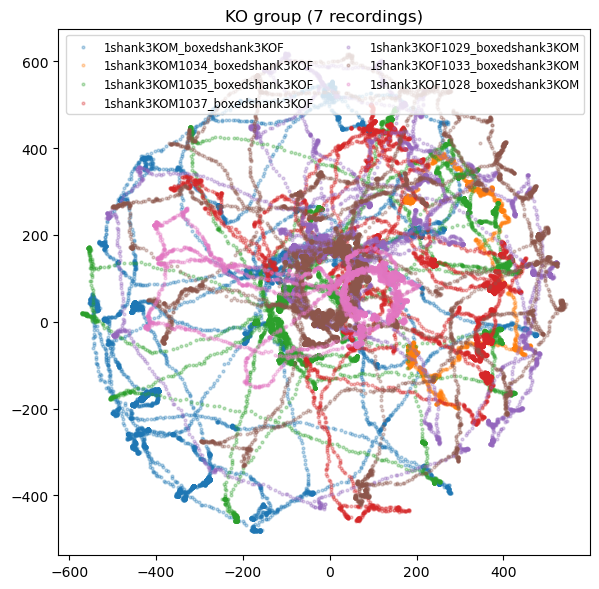

✔️ Saved KO plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_02/1shank3KOM_boxedshank3KOF/vis/KO_combined.png


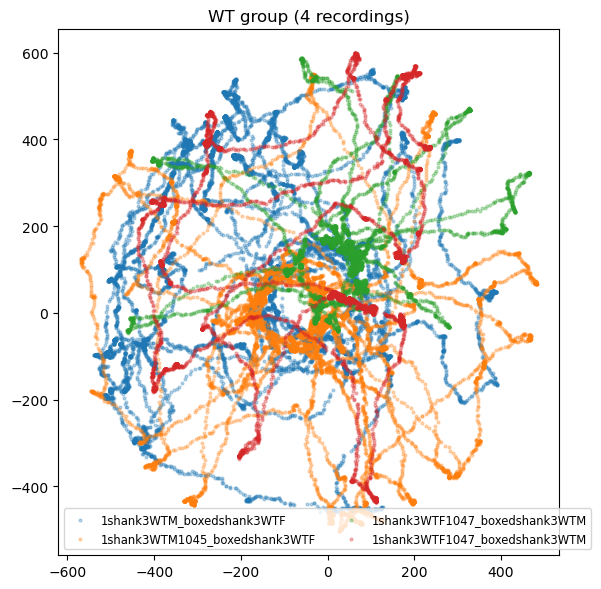

✔️ Saved WT plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_02/1shank3WTM_boxedshank3WTF/vis/WT_combined.png


In [5]:
from utlis.vis_valid_utlis.com_trace import plot_group_com


# 1. pull out your two columns
rec_paths = filtered_table.column('rec_path').to_pylist()
rec_files = filtered_table.column('rec_file').to_pylist()

# 2. split into two lists
of_paths = [p for p, f in zip(rec_paths, rec_files) if 'KO' in f]
tf_paths = [p for p, f in zip(rec_paths, rec_files) if 'WT' in f]
plot_group_com(of_paths, 'KO')
plot_group_com(tf_paths, 'WT')

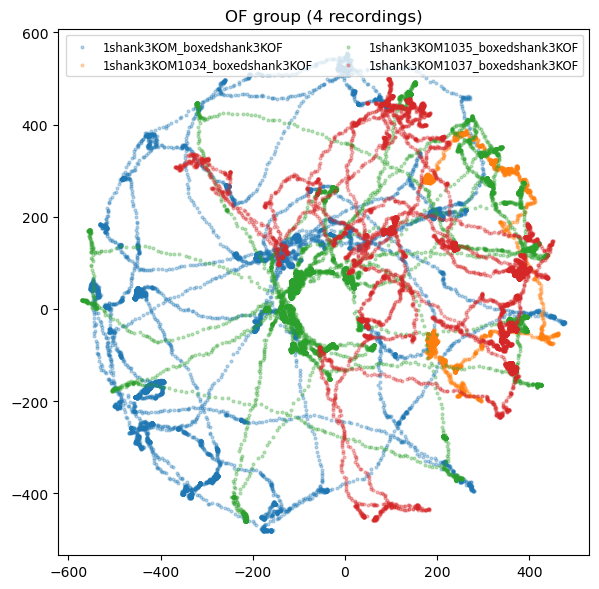

✔️ Saved OF plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_02/1shank3KOM_boxedshank3KOF/vis/OF_combined.png


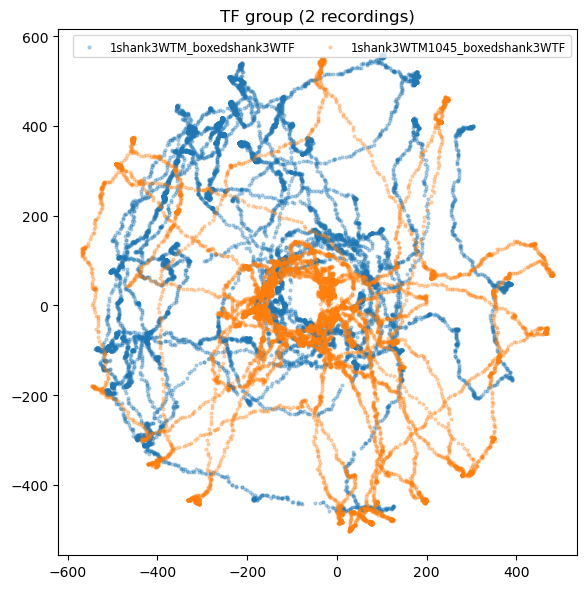

✔️ Saved TF plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_02/1shank3WTM_boxedshank3WTF/vis/TF_combined.png


In [18]:
from utlis.vis_valid_utlis.com_trace import plot_group_com


# 1. pull out your two columns
rec_paths = filtered_table.column('rec_path').to_pylist()
rec_files = filtered_table.column('rec_file').to_pylist()

# 2. split into two lists
of_paths = [p for p, f in zip(rec_paths, rec_files) if f.endswith('OF')]
tf_paths = [p for p, f in zip(rec_paths, rec_files) if f.endswith('TF')]
plot_group_com(of_paths, 'OF')
plot_group_com(tf_paths, 'TF')

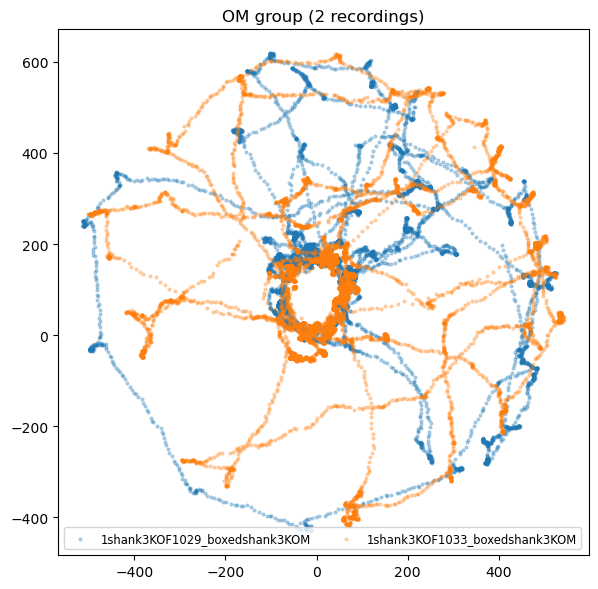

✔️ Saved OM plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_15/1shank3KOF1029_boxedshank3KOM/vis/OM_combined.png


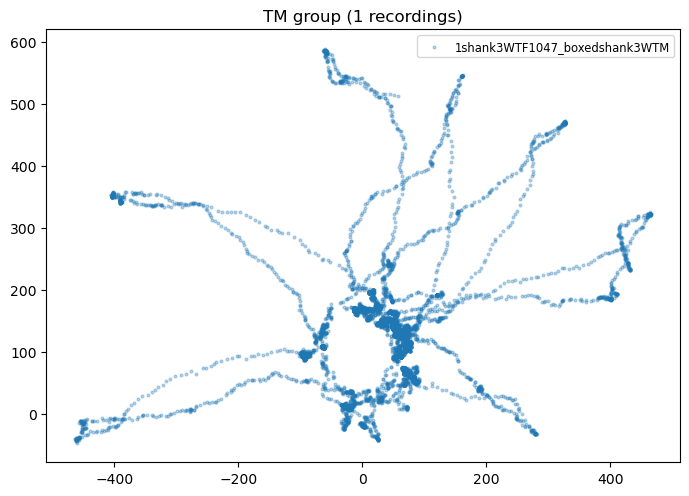

✔️ Saved TM plot to /data/big_rim/rsync_dcc_sum/25Apri_social/2025_05_15/1shank3WTF1047_boxedshank3WTM/vis/TM_combined.png


In [17]:
of_paths = [p for p, f in zip(rec_paths, rec_files) if f.endswith('OM')]
tf_paths = [p for p, f in zip(rec_paths, rec_files) if f.endswith('TM')]
plot_group_com(of_paths, 'OM')
plot_group_com(tf_paths, 'TM')